In [ ]:
# ==============================================================
# CLASSIFICATION BINAIRE MULTICRITÈRE (PyTorch + M2 Pro GPU)
# ==============================================================
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import re

from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [2]:
# --------------------------------------------------------------
# 1️. CONFIGURATION GPU MPS
# --------------------------------------------------------------
print("="*70)
print("CONFIGURATION GPU APPLE M2 PRO")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")
print(f"MPS compilé: {torch.backends.mps.is_built()}")

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"✅ Utilisation du device : {device}")
print("="*70, "\n")

CONFIGURATION GPU APPLE M2 PRO
PyTorch version: 2.4.1
MPS disponible: True
MPS compilé: True
✅ Utilisation du device : mps



### Étape A — Ingestion + typage + nettoyage

#### Ingestion 

In [6]:
data = pd.read_csv('data/dfforml2.csv')
data.head()

,consultation_type,type_prestation,type_observation,mode_sortie,status_verification,observations_verification,nom_patient_is_filled,distance_village_is_filled,age_patient_is_filled,registre_number_is_filled,...,verifierPrestationEnfant,quantite_total_prod_exists,quantite_total_act_exists,quantite_total_ex_exists,cout_total_prod_exists,cout_total_act_exists,cout_total_ex_exists,cout_mise_en_observation_exists,cout_evacuation_exists,nbre_jours_exists
0,1.0,34.0,NaN,59.0,a_corriger,Absence de: nom_patient,0,1,0,1,...,0,1,1,0,1,1,1,1,1,1
1,4.0,20.0,NaN,59.0,a_corriger,Absence de: registre_number,1,1,0,0,...,0,1,1,0,1,1,1,1,1,1
2,4.0,20.0,NaN,59.0,a_corriger,Absence de: registre_number,1,1,0,0,...,0,1,1,0,1,1,1,1,1,1
3,4.0,20.0,NaN,59.0,a_corriger,Absence de: registre_number,1,1,0,0,...,0,1,1,1,1,1,1,1,1,1
4,4.0,20.0,NaN,59.0,a_corriger,Absence de: registre_number,1,1,0,0,...,0,1,1,0,1,1,1,1,1,1


#### Nettoyage et typage

In [7]:
datacopy = data.copy()

In [8]:
datacopy['status_verification'].value_counts()

status_verification
a_corriger    833
validee       600
Name: count, dtype: int64

In [9]:
datacopy['observations_verification'].value_counts()

observations_verification
Quantité anormale d’acte Réduire la quantité à 1                                                600
RAS                                                                                             600
Bien et service non éligible pour la catégorie de patient                                       175
L’acte ne correspond pas avec le sexe du patient                                                 44
Absence de: registre_number                                                                       6
Montant d'évacuation anormal                                                                      4
Absence de: nom_patient                                                                           1
Chevauchement de date d'hospitalisation détecté                                                   1
Facture saisie avant date d'entrée; Date de sortie est avant la date d’entrée                     1
Prestation non éligible pour la Planification familiale avec type de prest

In [6]:
# Créer un nouveau dataframe équilibré avec 5000 'validee' et 5000 'a_corriger'
validee_df = datacopy[datacopy['status_verification'] == 'validee']
a_corriger_df = datacopy[datacopy['status_verification'] == 'a_corriger']

# Échantillonner 5000 de chaque, avec remise si nécessaire
validee_sample = validee_df.sample(n=5000, replace=True, random_state=42)
a_corriger_sample = a_corriger_df.sample(n=5000, replace=True, random_state=42)

# Concaténer les deux échantillons
balanced_df = pd.concat([validee_sample, a_corriger_sample], ignore_index=True)

# Mélanger les lignes pour éviter l'ordre
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Nouveau dataframe équilibré : {balanced_df.shape}")
print(balanced_df['status_verification'].value_counts())

Nouveau dataframe équilibré : (10000, 42)
status_verification
a_corriger    5000
validee       5000
Name: count, dtype: int64


In [8]:
datacopy=balanced_df.copy()

In [8]:
from sklearn.preprocessing import LabelEncoder

# Encoding the specified categorical variables in datacopy using sklearn (as PyTorch is primarily for model training, not data encoding)

le = LabelEncoder()
categorical_cols = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']

for col in categorical_cols:
    # Fill NaN values with a placeholder before encoding
    datacopy[col] = datacopy[col].fillna('unknown')
    # Encode the column
    datacopy[col] = le.fit_transform(datacopy[col].astype(str))

In [9]:
# Afficher des statistiques sur les colonnes encodées
for col in categorical_cols:
    print(f"\nStatistiques pour {col}:")
    print(datacopy[col].value_counts())
    print(f"Nombre de valeurs uniques: {datacopy[col].nunique()}")


Statistiques pour consultation_type:
consultation_type
3    7352
0    4936
4    1508
1    1128
2      81
Name: count, dtype: int64
Nombre de valeurs uniques: 5

Statistiques pour type_prestation:
type_prestation
8     7127
18    3041
19    1802
21     559
13     491
14     440
0      355
11     306
9      224
22     149
15     144
20      92
5       78
12      77
10      45
1       36
24      16
23      11
16       4
6        2
2        2
7        1
3        1
17       1
4        1
Name: count, dtype: int64
Nombre de valeurs uniques: 25

Statistiques pour type_observation:
type_observation
0    15005
Name: count, dtype: int64
Nombre de valeurs uniques: 1

Statistiques pour mode_sortie:
mode_sortie
2    12222
7     2673
1       57
6       20
0       15
3        8
4        7
5        3
Name: count, dtype: int64
Nombre de valeurs uniques: 8

Statistiques pour id_type_structure:
id_type_structure
1    12174
0     2030
4      458
3      177
2      166
Name: count, dtype: int64
Nombre de va

In [11]:
datacopy.head()

,consultation_type,type_prestation,type_observation,mode_sortie,status_verification,observations_verification,id_type_structure,nom_patient_is_filled,distance_village_is_filled,age_patient_is_filled,...,verifierPrestationEnfant,quantite_total_prod_exists,quantite_total_act_exists,quantite_total_ex_exists,cout_total_prod_exists,cout_total_act_exists,cout_total_ex_exists,cout_mise_en_observation_exists,cout_evacuation_exists,nbre_jours_exists
0,4,14,0,7,validee,NaN,1,1,1,0,...,0,1,1,0,1,1,1,1,1,1
1,0,18,0,2,validee,NaN,1,1,1,0,...,0,1,1,0,1,1,1,1,1,1
2,0,18,0,2,validee,NaN,1,1,1,0,...,0,1,1,0,1,1,1,1,1,1
3,0,18,0,7,validee,NaN,1,1,1,0,...,0,1,1,0,1,1,1,1,1,1
4,2,5,0,2,validee,RAS,1,1,1,0,...,0,1,1,0,1,1,1,1,1,1


In [9]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# ============================================================
# 1. PRÉPARATION DES DONNÉES
# ============================================================

# Features et target
X = datacopy.drop(columns=['status_verification', 'observations_verification'])
y = datacopy['status_verification'].map({'validee': 0, 'a_corriger': 1})

# Vérification valeurs nulles dans la target
assert y.isna().sum() == 0, "Des valeurs inconnues existent dans 'status_verification'"

# Split stratifié train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# 2. COLONNES CATÉGORIELLES
# ============================================================

# Ne garder que les colonnes catégorielles qui existent dans X
all_categorical = [
    'consultation_type', 'type_prestation',
    'type_observation', 'mode_sortie', 'id_type_structure'
]
categorical_features = [c for c in all_categorical if c in X.columns]

# Forcer le type 'category' (requis par LightGBM)
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

# ============================================================
# 3. DATASETS LIGHTGBM
# ============================================================

train_data = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=categorical_features,
    free_raw_data=False   # garder les données pour SHAP si besoin
)
test_data = lgb.Dataset(
    X_test, label=y_test,
    categorical_feature=categorical_features,
    reference=train_data,  # OBLIGATOIRE pour alignement encodage
    free_raw_data=False
)

# ============================================================
# 4. GESTION DU DÉSÉQUILIBRE DE CLASSES
# ============================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos  # pondération automatique

print(f"Classe 0 (validee)    : {neg}")
print(f"Classe 1 (a_corriger) : {pos}")
print(f"scale_pos_weight      : {scale_pos_weight:.2f}\n")

# ============================================================
# 5. PARAMÈTRES DU MODÈLE
# ============================================================

params = {
    'objective'         : 'binary',
    'metric'            : ['binary_logloss', 'auc'],  # suivre les 2 métriques
    'boosting_type'     : 'gbdt',
    'num_leaves'        : 31,
    'learning_rate'     : 0.05,
    'feature_fraction'  : 0.9,
    'bagging_fraction'  : 0.8,       # sous-échantillonnage lignes
    'bagging_freq'      : 5,         # fréquence du bagging
    'min_child_samples' : 20,        # évite overfitting sur petites classes
    'scale_pos_weight'  : scale_pos_weight,  # correction déséquilibre
    'verbose'           : -1         # silencer les warnings LightGBM
}

# ============================================================
# 6. ENTRAÎNEMENT
# ============================================================

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50)   # affiche les métriques toutes les 50 rounds
]

bst = lgb.train(
    params,
    train_data,
    num_boost_round=500,            # augmenté car early_stopping gère l'arrêt
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],  # noms lisibles dans les logs
    callbacks=callbacks
)

print(f"\nMeilleure itération : {bst.best_iteration}")

# ============================================================
# 7. PRÉDICTIONS
# ============================================================

y_pred_proba_test  = bst.predict(X_test,  num_iteration=bst.best_iteration)
y_pred_proba_train = bst.predict(X_train, num_iteration=bst.best_iteration)

# Seuil à 0.5 par défaut — à ajuster selon le contexte métier
THRESHOLD = 0.5
y_pred_binary = (y_pred_proba_test > THRESHOLD).astype(int)

# ============================================================
# 8. ÉVALUATION COMPLÈTE
# ============================================================

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()

acc         = accuracy_score(y_test, y_pred_binary)
prec        = precision_score(y_test, y_pred_binary, zero_division=0)
recall      = recall_score(y_test, y_pred_binary, zero_division=0)
f1          = f1_score(y_test, y_pred_binary, zero_division=0)
auc_train   = roc_auc_score(y_train, y_pred_proba_train)
auc_test    = roc_auc_score(y_test,  y_pred_proba_test)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # = recall classe 1
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*45)
print("         RÉSULTATS LIGHTGBM")
print("="*45)
print(f"  Accuracy         : {acc:.4f}")
print(f"  Precision        : {prec:.4f}")
print(f"  Recall           : {recall:.4f}")
print(f"  F1-score         : {f1:.4f}")
print(f"  AUC (train)      : {auc_train:.4f}")
print(f"  AUC (test)       : {auc_test:.4f}")
print(f"  Sensitivity test : {sensitivity:.4f}")
print(f"  Specificity test : {specificity:.4f}")
print("="*45)

# Overfit check
auc_gap = auc_train - auc_test
print(f"\n  Gap AUC train-test : {auc_gap:.4f}", end=" ")
print("⚠️ Overfitting possible" if auc_gap > 0.05 else "✅ OK")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['validee', 'a_corriger']))

print("Confusion Matrix:")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

Classe 0 (validee)    : 4000
Classe 1 (a_corriger) : 4000
scale_pos_weight      : 1.00

Training until validation scores don't improve for 50 rounds
[50]	train's binary_logloss: 0.558149	train's auc: 0.733316	test's binary_logloss: 0.559743	test's auc: 0.728318
[100]	train's binary_logloss: 0.548329	train's auc: 0.737139	test's binary_logloss: 0.552521	test's auc: 0.728296
Early stopping, best iteration is:
[70]	train's binary_logloss: 0.552195	train's auc: 0.734807	test's binary_logloss: 0.554568	test's auc: 0.729863

Meilleure itération : 70

         RÉSULTATS LIGHTGBM
  Accuracy         : 0.6945
  Precision        : 0.6470
  Recall           : 0.8560
  F1-score         : 0.7370
  AUC (train)      : 0.7348
  AUC (test)       : 0.7299
  Sensitivity test : 0.8560
  Specificity test : 0.5330

  Gap AUC train-test : 0.0049 ✅ OK

Classification Report:
              precision    recall  f1-score   support

     validee       0.79      0.53      0.64      1000
  a_corriger       0.65     

In [14]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Préparation des données pour LightGBM

# Features et target
X = datacopy.drop(columns=['status_verification', 'observations_verification'])  # Exclure la target et les colonnes non pertinentes
y = datacopy['status_verification'].map({'validee': 0, 'a_corriger': 1})  # Encoder la target binaire

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Spécifier les colonnes catégorielles pour LightGBM
categorical_features = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']

# Créer le dataset LightGBM
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features, reference=train_data)

# Paramètres du modèle
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# Entraînement
bst = lgb.train(params, train_data, num_boost_round=100, valid_sets=[test_data], callbacks=[lgb.early_stopping(50)] )

# Prédictions et évaluation
y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)
y_pred_binary = (y_pred > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_binary))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

[LightGBM] [Info] Number of positive: 4004, number of negative: 8000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53
[LightGBM] [Info] Number of data points in the train set: 12004, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333555 -> initscore=-0.692148
[LightGBM] [Info] Start training from score -0.692148
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

In [ ]:
import xgboost as xgb

# entraînement d’un classifieur XGBoost et calcul des métriques demandées

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# préparation des features / target comme dans le modèle LightGBM précédent
X = datacopy.drop(columns=["status_verification", "observations_verification"])
y = datacopy["status_verification"].map({"validee": 0, "a_corriger": 1})

# split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# instanciation / entraînement
clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
clf.fit(X_train, y_train)

# prédictions et probabilités
y_train_pred  = clf.predict(X_train)
y_train_prob  = clf.predict_proba(X_train)[:, 1]
y_test_pred   = clf.predict(X_test)
y_test_prob   = clf.predict_proba(X_test)[:, 1]

# métriques
acc        = accuracy_score(y_test, y_test_pred)
prec       = precision_score(y_test, y_test_pred)
recall     = recall_score(y_test, y_test_pred)
f1         = f1_score(y_test, y_test_pred)
auc_tr     = roc_auc_score(y_train, y_train_prob)
auc_te     = roc_auc_score(y_test,  y_test_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
sensitivity = tp / (tp + fn)      # rappel
specificity = tn / (tn + fp)

print("=== Résultats XGBoost ===")
print(f"Accuracy         : {acc:.4f}")
print(f"Precision        : {prec:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1‑score         : {f1:.4f}")
print(f"AUC (train)      : {auc_tr:.4f}")
print(f"AUC (test)       : {auc_te:.4f}")
print(f"Sensitivity test : {sensitivity:.4f}")
print(f"Specificity test : {specificity:.4f}")

Entraîner le modèle

In [23]:
def train_pipeline(df: pd.DataFrame, save_path="pipeline_status.joblib"):
    # 1) features
    df_feat = build_features(df)

    # 2) X / y
    y = df_feat["status_verification"].astype(str)

    cat_cols = ["consultation_type", "type_prestation", "type_observation", "mode_sortie"]
    # on garde les colonnes qui existent
    cat_cols = [c for c in cat_cols if c in df_feat.columns]

    # toutes les features qu'on veut utiliser
    feature_cols = [c for c in df_feat.columns if c != "status_verification"]

    X = df_feat[feature_cols].copy()

    # 3) split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4) prétraitement
    numeric_features = [c for c in X.columns if c not in cat_cols]
    categorical_features = cat_cols

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_features),
        ]
    )

    # 5) modèle (LightGBM si dispo sinon fallback sklearn)
    try:
        import lightgbm as lgb
        clf = lgb.LGBMClassifier(
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42
        )
    except Exception:
        from sklearn.ensemble import HistGradientBoostingClassifier
        clf = HistGradientBoostingClassifier(random_state=42)

    # 6) class weights (si classes déséquilibrées)
    classes = np.unique(y_train)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight = {c: w for c, w in zip(classes, cw)}
    try:
        clf.set_params(class_weight=class_weight)
    except Exception:
        pass

    # 7) pipeline final : preprocess -> model
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", clf)
    ])

    model.fit(X_train, y_train)

    # 8) évaluation
    y_pred = model.predict(X_test)
    print("\n=== Classification report ===")
    print(classification_report(y_test, y_pred, digits=4))
    print("\n=== Confusion matrix ===")
    print(confusion_matrix(y_test, y_pred, labels=classes))

    # 9) save
    joblib.dump({"model": model, "feature_builder": build_features}, save_path)
    print(f"\n✅ Sauvegardé: {save_path}")

    return model


Prédire une facture (1 ligne)

In [ ]:
def predict_one(row: dict, model_path="pipeline_status.joblib"):
    saved = joblib.load(model_path)
    model = saved["model"]
    fb = saved["feature_builder"]

    df = pd.DataFrame([row])
    df_feat = fb(df)

    X = df_feat.drop(columns=["status_verification"], errors="ignore")
    pred = model.predict(X)[0]

    proba = None
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)[0]
        proba = {model.classes_[i]: float(p[i]) for i in range(len(model.classes_))}

    return {"status_pred": pred, "proba": proba}


In [ ]:

# Nettoyage
X[vars_num] = X[vars_num].fillna(0)
X[vars_cat] = X[vars_cat].fillna("inconnu")

# Encodage
for col in vars_cat:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# --------------------------------------------------------------
# 3. ÉQUILIBRAGE DES CLASSES
# --------------------------------------------------------------
print("Avant SMOTE :", np.bincount(y))
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print("Après SMOTE :", np.bincount(y_res))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

In [ ]:
# --------------------------------------------------------------
# 4️⃣ CONVERSION EN TENSEURS PyTorch
# --------------------------------------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, "values") else y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values if hasattr(y_test, "values") else y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

In [ ]:
# --------------------------------------------------------------
# 5. DÉFINITION DU MODÈLE (MLP)
# --------------------------------------------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

# --------------------------------------------------------------
# 6. ENTRAÎNEMENT
# --------------------------------------------------------------
EPOCHS = 30
best_f1, patience, wait = 0, 5, 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).view(-1, 1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        preds, trues = [], []
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds.extend(outputs.cpu().numpy())
            trues.extend(yb.numpy())

        preds_bin = (np.array(preds).flatten() > 0.5).astype(int)
        f1 = f1_score(trues, preds_bin)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f} - F1: {f1:.4f}")

    # Early stopping
    if f1 > best_f1:
        best_f1, wait = f1, 0
        torch.save(model.state_dict(), "best_model_mps.pt")
    else:
        wait += 1
        if wait >= patience:
            print("⏹️  Early stopping.")
            break

Avant SMOTE : [10000 10000]
Après SMOTE : [10000 10000]
Epoch 1/30 - Loss: 0.5058 - F1: 0.8823
Epoch 2/30 - Loss: 0.3019 - F1: 0.9025
Epoch 3/30 - Loss: 0.2539 - F1: 0.9115
Epoch 4/30 - Loss: 0.2531 - F1: 0.9087
Epoch 5/30 - Loss: 0.2351 - F1: 0.9120
Epoch 6/30 - Loss: 0.2343 - F1: 0.9116
Epoch 7/30 - Loss: 0.2429 - F1: 0.9146
Epoch 8/30 - Loss: 0.2511 - F1: 0.9145
Epoch 9/30 - Loss: 0.2349 - F1: 0.9175
Epoch 10/30 - Loss: 0.2254 - F1: 0.9183
Epoch 11/30 - Loss: 0.2364 - F1: 0.9152
Epoch 12/30 - Loss: 0.2345 - F1: 0.9156
Epoch 13/30 - Loss: 0.2327 - F1: 0.9152
Epoch 14/30 - Loss: 0.2313 - F1: 0.9172
Epoch 15/30 - Loss: 0.2172 - F1: 0.9195
Epoch 16/30 - Loss: 0.2214 - F1: 0.9208
Epoch 17/30 - Loss: 0.2310 - F1: 0.9220
Epoch 18/30 - Loss: 0.2180 - F1: 0.9222
Epoch 19/30 - Loss: 0.2112 - F1: 0.9226
Epoch 20/30 - Loss: 0.2229 - F1: 0.9240
Epoch 21/30 - Loss: 0.2181 - F1: 0.9198
Epoch 22/30 - Loss: 0.2174 - F1: 0.9190
Epoch 23/30 - Loss: 0.2006 - F1: 0.9302
Epoch 24/30 - Loss: 0.1995 - F1: 

/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_19754/3261235834.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mode

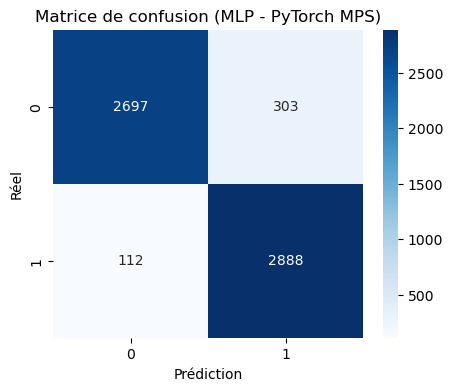

In [4]:

# --------------------------------------------------------------
# 7️⃣ ÉVALUATION FINALE
# --------------------------------------------------------------
model.load_state_dict(torch.load("best_model_mps.pt"))
model.eval()
with torch.no_grad():
    y_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        y_pred.extend(outputs.cpu().numpy())
y_pred_bin = (np.array(y_pred).flatten() > 0.5).astype(int)

print("\n===== RAPPORT DE CLASSIFICATION =====")
print(classification_report(y_test, y_pred_bin))

cm = confusion_matrix(y_test, y_pred_bin)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion (MLP - PyTorch MPS)")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

# --------------------------------------------------------------
# 8️⃣ SAUVEGARDE DU RAPPORT
# --------------------------------------------------------------
with open("rapport_classification_torch.txt", "w", encoding="utf-8") as f:
    f.write("===== RAPPORT DE CLASSIFICATION (PyTorch M2 Pro) =====\n\n")
    f.write(classification_report(y_test, y_pred_bin))
    f.write(f"\nF1-score final : {best_f1:.4f}\n")
